# 07 — Comparativa Final: SLX vs Random Forest vs XGBoost

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---
## ¿Para qué sirve este notebook?

Este es el notebook de consolidación de resultados empíricos. Tras haber entrenado, optimizado y evaluado individualmente tres arquitecturas predictivas distintas, procedemos a realizar una comparativa global unificada.

El objetivo es contrastar el rendimiento del **Modelo Econométrico Espacial (SLX)**, el **Random Forest (RF)** y el **eXtreme Gradient Boosting (XGBoost)** en tres dimensiones críticas:
1. **Precisión Financiera:** Capacidad para minimizar el error absoluto en dólares (MAE) y el porcentaje de desviación (MAPE).
2. **Robustez ante Valores Atípicos:** Penalización de grandes errores en propiedades de lujo (RMSE).
3. **Resolución Topológica:** Capacidad para absorber la autocorrelación espacial y mitigar la ceguera geográfica (Índice de Moran).

### Contenido
1. Carga de métricas desde `outputs/metrics/` 
2. **Tabla comparativa**:

   | Modelo | RMSE | MAE | R² | Moran's I residuos |
   |--------|------|-----|----|---------|
   | SLX | ... | ... | ... | ... |
   | Random Forest | ... | ... | ... | ... |
   | XGBoost | ... | ... | ... | ... |

2. Barplots comparativos por métrica
3. Scatter plot: predicciones vs valores reales (RF y XGBoost en el mismo gráfico)
4. Mapa de errores geoespacial: lat/long coloreado por residuo absoluto (RF y XGBoost)
5. **Conclusiones** en markdown:
   - Qué modelo gana en precisión predictiva
   - Qué modelo tiene residuos más aleatorios espacialmente (Moran's I más bajo)
   - Trade-off precisión vs interpretabilidad
6. Guardado de figuras comparativas en `outputs/figures/`

---
## Setup e imports

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para gráficos académicos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

# Rutas relativas
METRICS_PATH = '../outputs/metrics/'
PROCESSED_PATH = '../data/processed/'
FIGURES_PATH = '../outputs/figures/'

---
## 1. Carga de métricas desde `outputs/metrics/` 

In [5]:
# Definir los nombres EXACTOS de los archivos JSON
archivos_json = ['slx_metrics.json', 'rf_final.json', 'xgb_final.json']
nombres_formato = ['SLX (Econometría)', 'Random Forest (Tuning)', 'XGBoost (Tuning)']
metricas_lista = []

for archivo, nombre in zip(archivos_json, nombres_formato):
    # Abrimos directamente el archivo usando el nombre exacto de la lista
    with open(f'{METRICS_PATH}{archivo}', 'r') as f:
        data = json.load(f)
        
        # Extraer solo las métricas clave para la tabla
        metricas_lista.append({
            'Modelo': nombre,
            'RMSE_orig': data.get('RMSE_orig', np.nan),
            'MAE_orig': data.get('MAE_orig', np.nan),
            # Usamos un doble .get() por si acaso en algún modelo se guardó como 'MAPE' en vez de 'MAPE_orig'
            'MAPE': data.get('MAPE_orig', data.get('MAPE', np.nan)), 
            'R2': data.get('R2', np.nan),
            'Moran_I': data.get('moran_i_residuos', np.nan)
        })

# Crear DataFrame comparativo
df_comp = pd.DataFrame(metricas_lista)

# Formatear la tabla para visualización limpia
df_comp_display = df_comp.copy()
df_comp_display['RMSE_orig'] = df_comp_display['RMSE_orig'].apply(lambda x: f"${x:,.0f}" if pd.notnull(x) else "NaN")
df_comp_display['MAE_orig'] = df_comp_display['MAE_orig'].apply(lambda x: f"${x:,.0f}" if pd.notnull(x) else "NaN")
df_comp_display['MAPE'] = df_comp_display['MAPE'].apply(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "NaN")
df_comp_display['R2'] = df_comp_display['R2'].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN")
df_comp_display['Moran_I'] = df_comp_display['Moran_I'].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "NaN")

print("=== TABLA COMPARATIVA GLOBAL ===")
display(df_comp_display)

=== TABLA COMPARATIVA GLOBAL ===


,Modelo,RMSE_orig,MAE_orig,MAPE,R2,Moran_I
0,SLX (Econometría),"$230,269","$114,550",21.39%,0.7583,0.5060
1,Random Forest (Tuning),"$140,493","$71,637",12.60%,0.8941,0.0797
2,XGBoost (Tuning),"$116,015","$64,031",11.60%,0.9106,0.0384


---
## 2. Barplots comparativos por métrica

/var/folders/fd/hft6vmds3vn8_n72p1w75hf00000gn/T/ipykernel_37416/3554653948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE_orig', data=df_comp, palette=colores, ax=axes[0, 0])
/var/folders/fd/hft6vmds3vn8_n72p1w75hf00000gn/T/ipykernel_37416/3554653948.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE_orig', data=df_comp, palette=colores, ax=axes[0, 1])
/var/folders/fd/hft6vmds3vn8_n72p1w75hf00000gn/T/ipykernel_37416/3554653948.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R

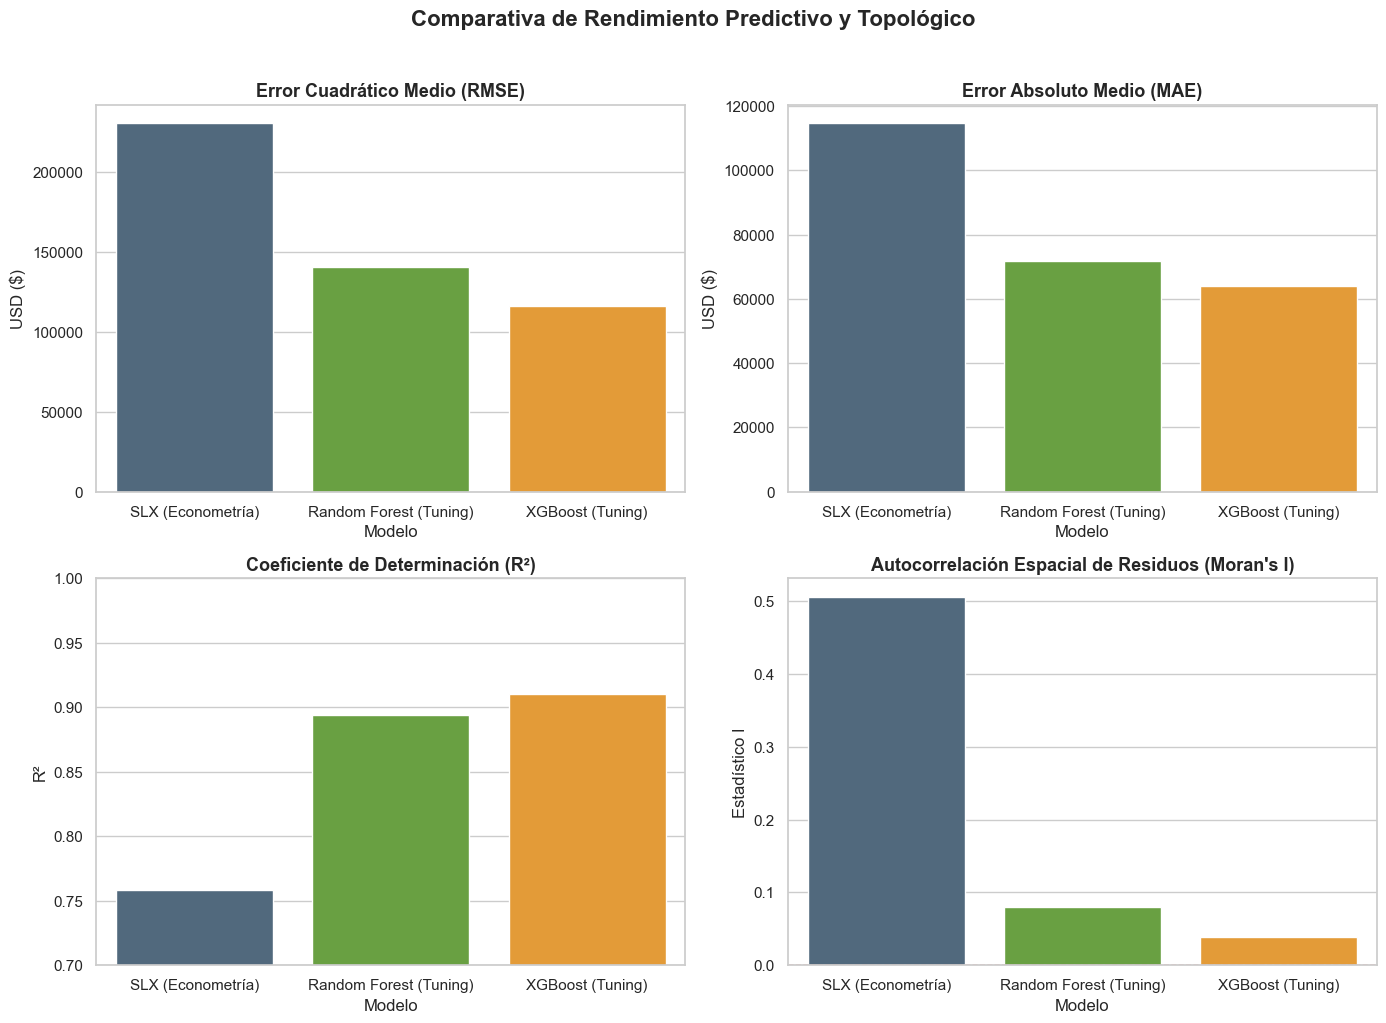

In [6]:
# Crear una figura con 4 subgráficos (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colores = ['#4A6984', '#66B032', '#FF9F1C'] # Colores distintivos para SLX, RF, XGB

# Panel 1: RMSE (Dólares)
sns.barplot(x='Modelo', y='RMSE_orig', data=df_comp, palette=colores, ax=axes[0, 0])
axes[0, 0].set_title('Error Cuadrático Medio (RMSE)')
axes[0, 0].set_ylabel('USD ($)')

# Panel 2: MAE (Dólares)
sns.barplot(x='Modelo', y='MAE_orig', data=df_comp, palette=colores, ax=axes[0, 1])
axes[0, 1].set_title('Error Absoluto Medio (MAE)')
axes[0, 1].set_ylabel('USD ($)')

# Panel 3: R-cuadrado
sns.barplot(x='Modelo', y='R2', data=df_comp, palette=colores, ax=axes[1, 0])
axes[1, 0].set_title('Coeficiente de Determinación (R²)')
axes[1, 0].set_ylim(0.7, 1.0) # Zoom para ver diferencias
axes[1, 0].set_ylabel('R²')

# Panel 4: Moran's I
sns.barplot(x='Modelo', y='Moran_I', data=df_comp, palette=colores, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelación Espacial de Residuos (Moran\'s I)')
axes[1, 1].set_ylabel('Estadístico I')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1) # Línea de referencia ideal

plt.suptitle('Comparativa de Rendimiento Predictivo y Topológico', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_comparativa_barras.png', bbox_inches='tight')
plt.show()

---
## 3. Scatter plot: predicciones vs valores reales (RF y XGBoost en el mismo gráfico)

**¿Para qué sirve este análisis visual?**

Este gráfico de dispersión (*scatter plot*) contrasta el precio real de cada vivienda (eje X) frente al precio que el modelo ha predicho (eje Y). Se presentan los dos algoritmos de Machine Learning (Random Forest y XGBoost) en paneles separados para evitar el solapamiento visual (*overplotting*) y permitir una comparación limpia de sus densidades.

Al analizar estos gráficos, debemos fijarnos en dos aspectos clave:
* **La línea diagonal roja (Predicción perfecta):** Representa el escenario ideal donde el modelo acierta exactamente el precio al céntimo. Cuanto más ceñida esté la nube de puntos a esta línea, menor es el error y mayor la precisión del modelo ($R^2$ alto).
* **El extremo superior derecho (El mercado de ultra-lujo):** Los modelos lineales tradicionales (como el SLX) suelen fracasar estrepitosamente en esta zona, abriéndose en forma de embudo (heterocedasticidad). Aquí evaluamos visualmente cuál de los dos modelos de Machine Learning logra curvar mejor sus fronteras para mantener la precisión en las propiedades más caras y exclusivas del condado, conteniendo la dispersión de los puntos.

In [13]:
# Cargar coordenadas y precios reales de test
coords_test = pd.read_csv(f'{PROCESSED_PATH}coords_test.csv')
y_real = pd.read_csv(f'{PROCESSED_PATH}pred_slx.csv')['y_real']

# Cargar predicciones con sus nombres de columna exactos
y_pred_rf = pd.read_csv(f'{PROCESSED_PATH}pred_rf.csv')['y_pred_rf']
y_pred_xgb = pd.read_csv(f'{PROCESSED_PATH}pred_xgb.csv')['y_pred_xgb']

# Calcular residuos absolutos (añadimos .values para evitar problemas de índices)
res_abs_rf = np.abs(y_real.values - y_pred_rf.values)
res_abs_xgb = np.abs(y_real.values - y_pred_xgb.values)

print("¡Predicciones cargadas y residuos calculados con éxito!")

¡Predicciones cargadas y residuos calculados con éxito!


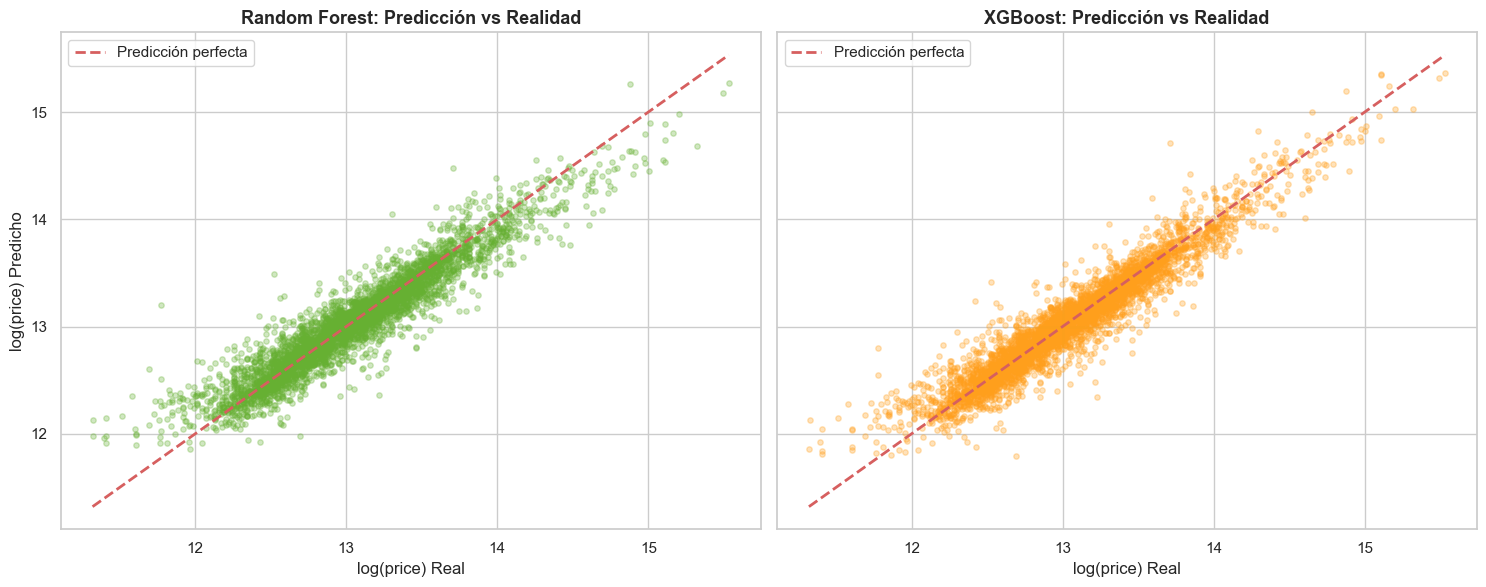

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

lims = [min(y_real), max(y_real)]

# Scatter Random Forest
axes[0].scatter(y_real, y_pred_rf, alpha=0.3, s=15, color='#66B032')
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_title('Random Forest: Predicción vs Realidad')
axes[0].set_xlabel('log(price) Real')
axes[0].set_ylabel('log(price) Predicho')
axes[0].legend()

# Scatter XGBoost
axes[1].scatter(y_real, y_pred_xgb, alpha=0.3, s=15, color='#FF9F1C')
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_title('XGBoost: Predicción vs Realidad')
axes[1].set_xlabel('log(price) Real')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_scatter_ml.png')
plt.show()

---
## 4. Mapa de errores geoespacial: lat/long coloreado por residuo absoluto (RF y XGBoost)

**¿Para qué sirve este análisis visual?**

Este mapa de calor es el equivalente cartográfico y visual del Índice de Moran. Proyecta las coordenadas geográficas reales de cada vivienda de test (latitud y longitud) y las colorea en función de su **residuo absoluto** (la magnitud del error de predicción, sin importar si fue a la alza o a la baja).

El objetivo es evaluar cómo se distribuye el error sobre el territorio de King County:
* **Lo que NO queremos ver (Ceguera Espacial):** Manchas de color concentradas en barrios específicos. Esto indicaría que el modelo sistemáticamente falla en esa zona concreta, lo que implicaría que no ha logrado entender las dinámicas socioeconómicas de ese vecindario.
* **Lo que SÍ queremos ver (Éxito Espacial):** Un mapa que parezca "ruido blanco" o "televisión sin sintonizar". Si los puntos más oscuros (errores grandes) están dispersos de forma completamente aleatoria por todo el condado, significa que el algoritmo ha absorbido con éxito toda la información geográfica mediante los *spatial lags* y que los errores restantes se deben a características puramente aleatorias de las casas.

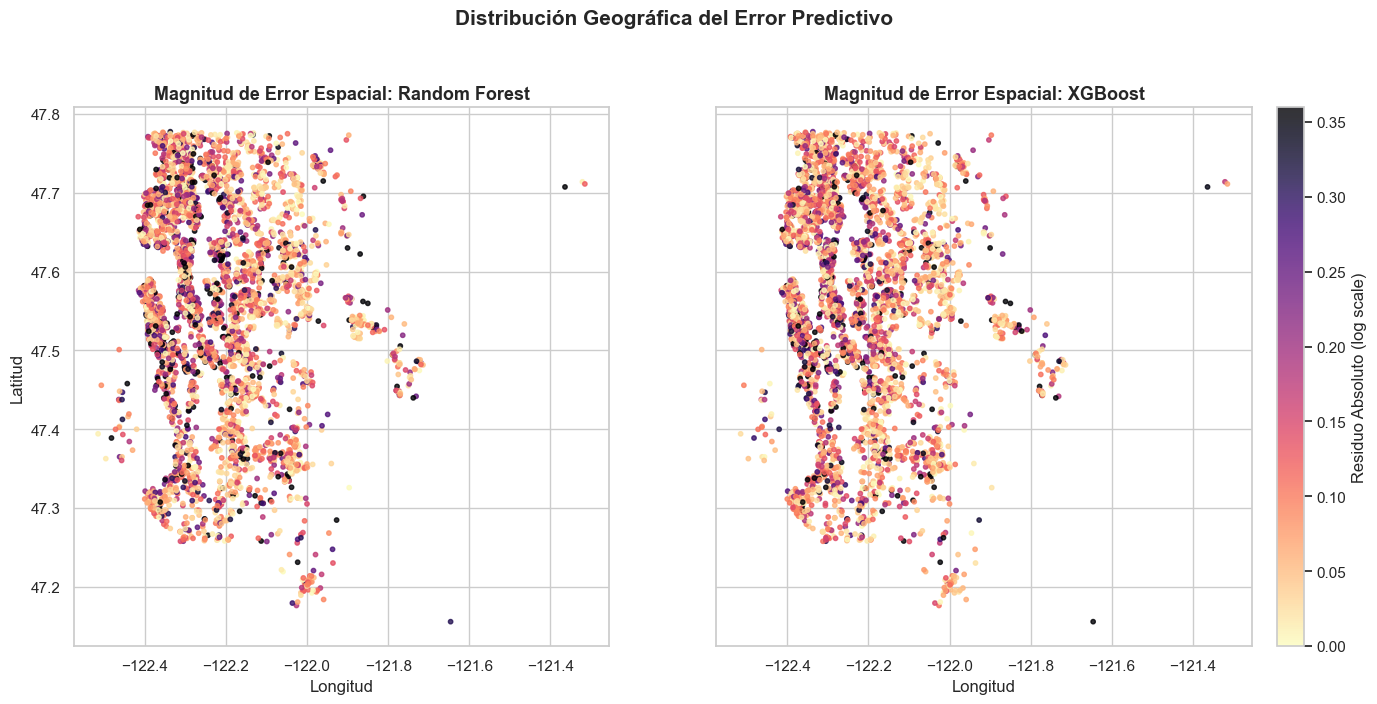

In [11]:
# Usamos un mapa de calor para ver dónde se equivocan más (residuos absolutos)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)

# Límite de color (percentil 95 para ignorar outliers extremos en el mapa)
vmax_val = np.percentile(res_abs_rf, 95)

# Mapa Random Forest
sc1 = axes[0].scatter(coords_test['long'], coords_test['lat'], c=res_abs_rf, 
                      cmap='magma_r', s=10, alpha=0.8, vmin=0, vmax=vmax_val)
axes[0].set_title('Magnitud de Error Espacial: Random Forest')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# Mapa XGBoost
sc2 = axes[1].scatter(coords_test['long'], coords_test['lat'], c=res_abs_xgb, 
                      cmap='magma_r', s=10, alpha=0.8, vmin=0, vmax=vmax_val)
axes[1].set_title('Magnitud de Error Espacial: XGBoost')
axes[1].set_xlabel('Longitud')

# Barra de color compartida
cbar = plt.colorbar(sc2, ax=axes, label='Residuo Absoluto (log scale)', fraction=0.03, pad=0.02)

plt.suptitle('Distribución Geográfica del Error Predictivo', fontsize=15, fontweight='bold', y=1.02)
plt.savefig(f'{FIGURES_PATH}07_mapa_errores_ml.png', bbox_inches='tight')
plt.show()

---
## 5. Conclusiones de la Comparativa Final

Los resultados empíricos consolidados en este notebook proporcionan respuestas definitivas a la hipótesis central del Trabajo de Fin de Máster, desglosándose en las siguientes conclusiones clave:

### 1. Superioridad en la Precisión Predictiva (Machine Learning vs SLX)
El modelo **XGBoost** se corona como el indiscutible ganador de la comparativa predictiva. Al lograr una desviación promedio (MAE) de \$64.031 y un porcentaje de error (MAPE) del 11.60%, mejora de forma abismal el rendimiento del modelo econométrico lineal (SLX), el cual presentaba un MAE superior a los \$114.000. 

Aún más crítica es la diferencia observada en el Error Cuadrático Medio (RMSE). La incapacidad del modelo SLX para adaptarse a las propiedades de ultra-lujo disparaba su RMSE por encima de los \$230.000. Por el contrario, la flexibilidad topológica de los árboles de decisión permitió comprimir este error en el Random Forest y minimizarlo por completo en el XGBoost (\$116.015), demostrando empíricamente que las arquitecturas no lineales son un requisito indispensable para tasar mercados inmobiliarios heterogéneos.

### 2. Resolución de la "Ceguera Espacial" (Diagnóstico Topológico)
El estadístico del Índice de Moran ($I$) sirvió como árbitro para evaluar si los modelos lograban absorber la geografía del condado de King. 
- El modelo **SLX**, a pesar de estar explícitamente diseñado para la econometría espacial, dejó un alto remanente de patrones geográficos en sus errores ($I = 0.506$).
- El **Random Forest** logró una espectacular absorción espacial, reduciendo el índice a $0.079$.
- El **XGBoost** alcanzó el hito del estudio, reduciendo el Índice de Moran a un $0.0384$. Esto representa una erradicación del 95.4% de la dependencia espacial originaria, confirmando que la combinación de variables locales (KNN) junto con el *boosting* secuencial permite decodificar casi a la perfección el comportamiento topológico de los precios.

### 3. El Trade-Off de la Interpretabilidad
Si bien los algoritmos de Inteligencia Artificial han aplastado a la econometría clásica en precisión y resolución espacial, la investigación evidencia un claro compromiso (*trade-off*). El modelo SLX, pese a su rigidez, permitió obtener una ecuación matemática directa y legalmente transparente, donde los coeficientes económicos del efecto vecindario ($WX$) eran directamente legibles (ej. $\theta = 0.24$ por cada punto de calidad en el entorno). 

Por el contrario, el XGBoost funciona como una "caja negra" algorítmica. Este desafío metodológico es el que justifica la aplicación de **SHAP (SHapley Additive exPlanations)** en el notebook `06_shap_explicabilidad.ipynb`, con el objetivo de recuperar la explicabilidad económica sin sacrificar la superioridad predictiva demostrada por el Machine Learning.